In [1]:
import os
import json
import pandas as pd
# from datetime import datetime
from dotenv import load_dotenv

from options import OptionSurface, Deribit, OKX, Bybit
from portfolio_management import Portfolio
from api_client import TradingDeskAPI
# from scanner import MarketScanner

In [226]:
# Initialize all classes and parameters

# load_dotenv(r"D:/OneDrive/Trading/Prediction Markets/Moreton Capital/.env")
load_dotenv(r"C:/Users/brian/OneDrive/Trading/Prediction Markets/Moreton Capital/.env")
BASE_URL = os.getenv("BASE_URL")
USER_EMAIL = os.getenv("USER_EMAIL")
USER_PASSWORD = os.getenv("USER_PASSWORD")
JWT_TOKEN = os.getenv("JWT")
DATA_DIR = os.getenv("DATA_DIR")
FRACTION = float(os.getenv("FRACTION"))
MAX_POSITION = float(os.getenv("MAX_POSITION"))
ENTRY_EV_THRESHOLD = float(os.getenv("ENTRY_EV_THRESHOLD")) # require 1% edge, default = 0
EXIT_EV_THRESHOLD = float(os.getenv("EXIT_EV_THRESHOLD"))
print(BASE_URL)

with open(f"{DATA_DIR}/crypto_tag_ids.json", "r") as f:
    crypto_tag_ids = set(json.load(f))

s = OptionSurface()
portfolio = Portfolio()
api = TradingDeskAPI(base_url=BASE_URL, email=USER_EMAIL, password=USER_PASSWORD, token=JWT_TOKEN)
# scanner = MarketScanner(api=api)

# target_expiry_str = "25DEC26"
# target_expiry = datetime.strptime(target_expiry_str, "%d%b%y").strftime("%Y%m%d")

currencies = ["BTC", "ETH"]
# currencies = ["BTC", "ETH", "HYPE", "SOL", "ZEC"]

https://alphasignal-dev.moretoncp.com


In [227]:
# 9. Get current markets
all_markets_df = api.get_all_markets(DATA_DIR=DATA_DIR, count_limit=10, liquidity_num_min=10000, volume_num_min=5000)
all_markets_df.head()

Fetched 100 markets | Total: 100
Fetched 100 markets | Total: 200
Fetched 100 markets | Total: 300
Fetched 100 markets | Total: 400
Fetched 100 markets | Total: 500
Fetched 100 markets | Total: 600
Fetched 100 markets | Total: 700
Fetched 100 markets | Total: 800
Fetched 100 markets | Total: 900
Fetched 100 markets | Total: 1,000


,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,version,negRiskMarketID,seriesColor,showGmpSeries,showGmpOutcome,oneHourPriceChange,umaResolutionStatus,eventStartTime,gameStartTime,groupItemRange
0,559651,Xi Jinping out before 2027?,0xa467b14d51f01b957109d9cbb1d6c124fab2a089d52e...,xi-jinping-out-before-2027,,2026-12-31T00:00:00Z,165852.97162,2025-07-03T20:37:00.228Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
1,559652,Will Gavin Newsom win the 2028 Democratic pres...,0x0f49db97f71c68b1e42a6d16e3de93d85dbf7d4148e3...,will-gavin-newsom-win-the-2028-democratic-pres...,,2028-11-07T00:00:00Z,300589.71633,2025-07-11T18:35:56.805Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN
2,559653,Will Alexandria Ocasio-Cortez win the 2028 Dem...,0xe6bcc2f1dd025ce5e1833190f7c60a71171c94f805df...,will-alexandria-ocasio-cortez-win-the-2028-dem...,,2028-11-07T00:00:00Z,324397.56997,2025-07-11T18:35:59.075Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN
3,559654,Will Pete Buttigieg win the 2028 Democratic pr...,0x4c325469d9b516ef4e6b8f73a81a12607dec075e3c2f...,will-pete-buttigieg-win-the-2028-democratic-pr...,,2028-11-07T00:00:00Z,523131.81014,2025-07-11T18:35:58.818Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN
4,559655,Will Josh Shapiro win the 2028 Democratic pres...,0xd65891729ce093cc12236856837eba1a0872fc7998fd...,will-josh-shapiro-win-the-2028-democratic-pres...,,2028-11-07T00:00:00Z,477356.5287,2025-07-11T18:36:01.098Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN


In [231]:
all_markets_df["endDate"] = pd.to_datetime(all_markets_df["endDate"], utc=True)
all_markets_df[all_markets_df["endDate"] < (all_markets_df["endDate"] + pd.Timedelta(hours=1))]

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,version,negRiskMarketID,seriesColor,showGmpSeries,showGmpOutcome,oneHourPriceChange,umaResolutionStatus,eventStartTime,gameStartTime,groupItemRange
0,559651,Xi Jinping out before 2027?,0xa467b14d51f01b957109d9cbb1d6c124fab2a089d52e...,xi-jinping-out-before-2027,,2026-12-31 00:00:00+00:00,165852.97162,2025-07-03T20:37:00.228Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
1,559652,Will Gavin Newsom win the 2028 Democratic pres...,0x0f49db97f71c68b1e42a6d16e3de93d85dbf7d4148e3...,will-gavin-newsom-win-the-2028-democratic-pres...,,2028-11-07 00:00:00+00:00,300589.71633,2025-07-11T18:35:56.805Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN
2,559653,Will Alexandria Ocasio-Cortez win the 2028 Dem...,0xe6bcc2f1dd025ce5e1833190f7c60a71171c94f805df...,will-alexandria-ocasio-cortez-win-the-2028-dem...,,2028-11-07 00:00:00+00:00,324397.56997,2025-07-11T18:35:59.075Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN
3,559654,Will Pete Buttigieg win the 2028 Democratic pr...,0x4c325469d9b516ef4e6b8f73a81a12607dec075e3c2f...,will-pete-buttigieg-win-the-2028-democratic-pr...,,2028-11-07 00:00:00+00:00,523131.81014,2025-07-11T18:35:58.818Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN
4,559655,Will Josh Shapiro win the 2028 Democratic pres...,0xd65891729ce093cc12236856837eba1a0872fc7998fd...,will-josh-shapiro-win-the-2028-democratic-pres...,,2028-11-07 00:00:00+00:00,477356.5287,2025-07-11T18:36:01.098Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1130015,Will the Liberal Democratic Party of Russia (L...,0x8c48f3acf4177b5ceb012a8a2dc7a9c219eeae4a032d...,will-the-liberal-democratic-party-of-russia-ld...,NaN,2026-09-30 00:00:00+00:00,161227.58171,2026-01-07T21:34:52.030175Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0xc194d621e2ef9468b86ed0db1328fd8d56ae8fba1e21...,NaN,False,False,NaN,NaN,NaN,NaN,NaN
996,1130016,Will New People (NL) gain the most seats in th...,0xc9615bb82d6535d630ff98e8094060bc767d8b944651...,will-new-people-nl-gain-the-most-seats-in-the-...,NaN,2026-09-30 00:00:00+00:00,134624.92576,2026-01-07T21:34:54.347508Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0xc194d621e2ef9468b86ed0db1328fd8d56ae8fba1e21...,NaN,False,False,NaN,NaN,NaN,NaN,NaN
997,1130017,Will Rodina gain the most seats in the next Ru...,0x2636a06ef9192d50bf0100bf8c857cfe346e8b230978...,will-rodina-gain-the-most-seats-in-the-next-ru...,NaN,2026-09-30 00:00:00+00:00,160369.78892,2026-01-07T21:34:54.601762Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0xc194d621e2ef9468b86ed0db1328fd8d56ae8fba1e21...,NaN,False,False,NaN,NaN,NaN,NaN,NaN
998,1130018,Will Civic Platform (GP) gain the most seats i...,0x247eabb5ea2c716c277c52c35c91e65e5c7d016318e8...,will-civic-platform-gp-gain-the-most-seats-in-...,NaN,2026-09-30 00:00:00+00:00,427186.25969,2026-01-07T21:34:53.83938Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0xc194d621e2ef9468b86ed0db1328fd8d56ae8fba1e21...,NaN,False,False,NaN,NaN,NaN,

In [33]:
import re

df = all_markets_df.copy()

keywords = [
    "Fed ",
    "CPI",
    "Core CPI",
    "Jobs",
    "GDP",
    "Rate decisions",
    "Inflation",
]

pattern = "|".join(map(re.escape, keywords))

mask = (
    df["question"].fillna("").str.contains(pattern, case=False, regex=True)
    # | df["description"].fillna("").str.contains(pattern, case=False, regex=True)
)

matches = df.loc[mask].copy()
matches

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,feeType,feeSchedule,version,negRiskMarketID,seriesColor,showGmpSeries,showGmpOutcome,umaResolutionStatus,eventStartTime,gameStartTime
229,616902,Will no Fed rate cuts happen in 2026?,0xd4e77ba6f29fc093509d24f508631abd445ecf506bbd...,will-no-fed-rate-cuts-happen-in-2026,,2026-12-31T00:00:00Z,469152.94131,2025-09-29T22:24:45.988997Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,economics_fees,"{'exponent': 1, 'rate': 0.05, 'takerOnly': Tru...",v1,0xdcd7daabcacdc4ecf4f9a48d0a2708b52f356dd086c8...,,False,False,NaN,NaN,NaN
230,616903,Will 1 Fed rate cut happen in 2026?,0x5e082f0b57f47a29044aa35b4c5658393122e659d5fe...,will-1-fed-rate-cut-happen-in-2026,,2026-12-31T00:00:00Z,218087.9904,2025-09-29T22:24:47.834711Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,economics_fees,"{'exponent': 1, 'rate': 0.05, 'takerOnly': Tru...",v1,0xdcd7daabcacdc4ecf4f9a48d0a2708b52f356dd086c8...,,False,False,NaN,NaN,NaN
231,616904,Will 2 Fed rate cuts happen in 2026?,0xe0d9f508a249e0070db06eb7d1e1fb17eb23c963f6fb...,will-2-fed-rate-cuts-happen-in-2026,,2026-12-31T00:00:00Z,126332.29257,2025-09-29T22:24:47.580779Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,economics_fees,"{'exponent': 1, 'rate': 0.05, 'takerOnly': Tru...",v1,0xdcd7daabcacdc4ecf4f9a48d0a2708b52f356dd086c8...,,False,False,NaN,NaN,NaN
232,616905,Will 3 Fed rate cuts happen in 2026?,0x8d4966e84ae80f24b2e14643fdd45364e354229e11e2...,will-3-fed-rate-cuts-happen-in-2026,,2026-12-31T00:00:00Z,232410.6531,2025-09-29T22:24:49.652632Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,economics_fees,"{'exponent': 1, 'rate': 0.05, 'takerOnly': Tru...",v1,0xdcd7daabcacdc4ecf4f9a48d0a2708b52f356dd086c8...,,False,False,NaN,NaN,NaN
233,616906,Will 4 Fed rate cuts happen in 2026?,0xaece8d6062d3e3eb9845b32441a4ab06eb2ef332c022...,will-4-fed-rate-cuts-happen-in-2026,,2026-12-31T00:00:00Z,240700.83414,2025-09-29T22:24:50.161283Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,economics_fees,"{'exponent': 1, 'rate': 0.05, 'takerOnly': Tru...",v1,0xdcd7daabcacdc4ecf4f9a48d0a2708b52f356dd086c8...,,False,False,NaN,NaN,NaN
234,616907,Will 5 Fed rate cuts happen in 2026?,0x7ee722a07e0f84405f1267bc1c84eb95bd6348454453...,will-5-fed-rate-cuts-happen-in-2026,,2026-12-31T00:00:00Z,238555.37938,2025-09-29T22:24:49.907177Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,economics_fees,"{'exponent': 1, 'rate': 0.05, 'takerOnly': Tru...",v1,0xdcd7daabcacdc4ecf4f9a48d0a2708b52f356dd086c8...,,False,False,NaN,NaN,NaN
235,616908,Will 6 Fed rate cuts happen in 2026?,0x4914bfdd892a48c341b5e0f41ec10475a815f2277273...,will-6-fed-rate-cuts-happen-in-2026,,2026-12-31T00:00:00Z,278571.9043,2025-09-29T22:24:51.765988Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,economics_fees,"{'exponent': 1, 'rate': 0.05, 'takerOnly': Tru...",v1,0xdcd7daabcacdc4ecf4f9a48d0a2708b52f356dd086c8...,,False,False,NaN,NaN,NaN
236,616909,Will 7 Fed rate cuts happen in 2026?,0x2368d2604c9c2b95bc98c51bd50c66e5351caebf05b9...,will-7-fed-rate-cuts-happen-in-2026,,2026-12-31T00:00:00Z,320682.16399,2025-09-29T22:24:53.782864Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,economics_fees,"{'exponent': 1, 'rate': 0.05, 'takerOnly': Tru...",v1,0xdcd7daabcacdc4ecf4f9a48d0a2708b52f356dd086c8...,,False,False,NaN,NaN,NaN
237,616910,Will 8 Fed rate cuts happen in 2026?,0xfe28cb84a714b1a964290d7fd2587e71d57e905678c8...,will-8-fed-rate-cuts-happen-in-2026,,2026-12-31T00:00:00Z,267759.01722,2025-09-29T22:24:55.785043Z,https://polyma

In [38]:
markets_df = scanner.scan_market(matches)

In [43]:
markets_df["createdAt"] = pd.to_datetime(markets_df["createdAt"], utc=True)
markets_df["endDate"] = pd.to_datetime(markets_df["endDate"], utc=True)

In [80]:
markets_df.iloc[1]["description"]

'This market will resolve according to the exact amount of cuts of 25 basis points in 2026 by the Fed (including any cuts made during the December meeting).\n\nEmergency rate cuts outside of scheduled FOMC meetings will also count toward the total number of cuts in 2026. This market will remain open until December 31, 2026, 11:59 PM ET, to account for any such emergency actions.\n\nFor example, if the Fed cuts rates by 50 bps after a meeting, it would be considered 2 cuts (of 25 bps each).\n\nThis market will resolve early to "No" if the specified number of cuts becomes impossible — i.e., if more cuts have already occurred than the strike in question.\n\nNote that cuts between 1–24 bps (inclusive) will also be considered 1 rate cut.\n\nThe resolution source for this market will be FOMC statements after meetings scheduled in 2026 according to the official calendar: https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm. The level and change of the target federal funds rate is a

In [44]:
markets_df

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,gameStartTime,tokens,yes_token,no_token,yes_book,no_book,yes_bid,yes_ask,no_bid,no_ask
229,616902,Will no Fed rate cuts happen in 2026?,0xd4e77ba6f29fc093509d24f508631abd445ecf506bbd...,will-no-fed-rate-cuts-happen-in-2026,,2026-12-31 00:00:00+00:00,469152.94131,2025-09-29T22:24:45.988997Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[124036029200392690775979173409216679975471150...,1240360292003926907759791734092166799754711508...,2129459220502296934673095510377339190199333022...,{'market': '0xd4e77ba6f29fc093509d24f508631abd...,{'market': '0xd4e77ba6f29fc093509d24f508631abd...,0.865,0.866,0.134,0.135
230,616903,Will 1 Fed rate cut happen in 2026?,0x5e082f0b57f47a29044aa35b4c5658393122e659d5fe...,will-1-fed-rate-cut-happen-in-2026,,2026-12-31 00:00:00+00:00,218087.9904,2025-09-29T22:24:47.834711Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[113379839734351069617987084078322474966003108...,1133798397343510696179870840783224749660031088...,4805880501259937597026877747495624277220424152...,{'market': '0x5e082f0b57f47a29044aa35b4c565839...,{'market': '0x5e082f0b57f47a29044aa35b4c565839...,0.09,0.1,0.9,0.91
231,616904,Will 2 Fed rate cuts happen in 2026?,0xe0d9f508a249e0070db06eb7d1e1fb17eb23c963f6fb...,will-2-fed-rate-cuts-happen-in-2026,,2026-12-31 00:00:00+00:00,126332.29257,2025-09-29T22:24:47.580779Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[725355440178979247226957221722788285627330907...,7253554401789792472269572217227882856273309074...,8140714210450911092118752077507262684078984861...,{'market': '0xe0d9f508a249e0070db06eb7d1e1fb17...,{'market': '0xe0d9f508a249e0070db06eb7d1e1fb17...,0.025,0.026,0.974,0.975
232,616905,Will 3 Fed rate cuts happen in 2026?,0x8d4966e84ae80f24b2e14643fdd45364e354229e11e2...,will-3-fed-rate-cuts-happen-in-2026,,2026-12-31 00:00:00+00:00,232410.6531,2025-09-29T22:24:49.652632Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[958357050624723054596637414029007361773307336...,9583570506247230545966374140290073617733073368...,5212599495761992623385468843771534037011457561...,{'market': '0x8d4966e84ae80f24b2e14643fdd45364...,{'market': '0x8d4966e84ae80f24b2e14643fdd45364...,0.005,0.006,0.994,0.995
233,616906,Will 4 Fed rate cuts happen in 2026?,0xaece8d6062d3e3eb9845b32441a4ab06eb2ef332c022...,will-4-fed-rate-cuts-happen-in-2026,,2026-12-31 00:00:00+00:00,240700.83414,2025-09-29T22:24:50.161283Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[731974411272566801346008213235833560372612132...,7319744112725668013460082132358335603726121328...,7167761230524493664108550009773703819908184562...,{'market': '0xaece8d6062d3e3eb9845b32441a4ab06...,{'market': '0xaece8d6062d3e3eb9845b32441a4ab06...,0.003,0.004,0.996,0.997
234,616907,Will 5 Fed rate cuts happen in 2026?,0x7ee722a07e0f84405f1267bc1c84eb95bd6348454453...,will-5-fed-rate-cuts-happen-in-2026,,2026-12-31 00:00:00+00:00,238555.37938,2025-09-29T22:24:49.907177Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[292132524466617892504849654461007092141172561...,2921325244666178925048496544610070921411725617...,3976693969446000492529026670953163566090208179...,{'market': '0x7ee722a07e0f84405f1267bc1c84eb95...,{'market': '0x7ee722a07e0f84405f1267bc1c84eb95...,0.002,0.003,0.997,0.998
235,616908,Will 6 Fed rate cuts happen in 2026?,0x4914bfdd892a48c341b5e0f41ec10475a815f2277273...,will-6-fed-rate-cuts-happen-in-2026,,2026-12-31 00:00:00+00:00,278571.9043,2025-09-29T22:24:51.765988Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[77531340423610587

In [11]:
import requests
import pandas as pd

token_id = "32338220190071351435772801779725302244575775216413325951443816017994629993401"

url = "https://clob.polymarket.com/prices-history"
params = {
    "market": token_id,
    "interval": "max",
    "fidelity": 1,       # 1-minute resolution
}

data = requests.get(url, params=params).json()["history"]

df = pd.DataFrame(data)
df["timestamp"] = pd.to_datetime(df["t"], unit="s", utc=True)
df["price"] = df["p"]

In [12]:
df

,t,p,timestamp,price
0,1784950807,0.0485,2026-07-25 03:40:07+00:00,0.0485
1,1784951406,0.0485,2026-07-25 03:50:06+00:00,0.0485
2,1784952015,0.0485,2026-07-25 04:00:15+00:00,0.0485
3,1784952608,0.0485,2026-07-25 04:10:08+00:00,0.0485
4,1784953208,0.0485,2026-07-25 04:20:08+00:00,0.0485
...,...,...,...,...
4446,1787626822,0.0515,2026-08-25 03:00:22+00:00,0.0515
4447,1787627414,0.0520,2026-08-25 03:10:14+00:00,0.0520
4448,1787628010,0.0525,2026-08-25 03:20:10+00:00,0.0525
4449,1787628610,0.0525,2026-08-25 03:30:10+00:00,0.0525


In [45]:
df = markets_df.copy()

now_ts = int(time.time())

all_market_history = {}

for idx, row in df.iterrows():

    if idx == 1:
        break

    token_id = row["yes_token"]

    # Convert createdAt -> Unix timestamp
    created_at = row["createdAt"]
    start_ts = int(created_at.timestamp())

    print("\n" + "=" * 80)
    print(f"Market: {row['question']}")
    print(f"Created: {created_at}")
    print(
        f"Start: {datetime.fromtimestamp(start_ts, tz=timezone.utc)}"
    )

    try:
        history = get_history_chunked(
            token_id=token_id,
            start_ts=start_ts,
            end_ts=now_ts,
            chunk_days=15
        )

        # Keep market metadata
        history["market_index"] = idx
        history["question"] = row["question"]
        history["token_id"] = token_id

        all_market_history[idx] = history

        print(f"Downloaded {len(history):,} observations")

    except Exception as e:
        print(f"ERROR: {e}")

price_history_df = pd.concat(
    all_market_history.values(),
    ignore_index=True
)

print(price_history_df.head())
print(price_history_df.shape)


Market: Will no Fed rate cuts happen in 2026?
Created: 2025-09-29 13:23:19.152108+00:00
Start: 2025-09-29 13:23:19+00:00
2025-09-29 13:23:19+00:00 -> 2025-10-14 13:23:19+00:00
2025-10-14 13:23:19+00:00 -> 2025-10-29 13:23:19+00:00
2025-10-29 13:23:19+00:00 -> 2025-11-13 13:23:19+00:00
2025-11-13 13:23:19+00:00 -> 2025-11-28 13:23:19+00:00
2025-11-28 13:23:19+00:00 -> 2025-12-13 13:23:19+00:00
2025-12-13 13:23:19+00:00 -> 2025-12-28 13:23:19+00:00
2025-12-28 13:23:19+00:00 -> 2026-01-12 13:23:19+00:00
2026-01-12 13:23:19+00:00 -> 2026-01-27 13:23:19+00:00
2026-01-27 13:23:19+00:00 -> 2026-02-11 13:23:19+00:00
2026-02-11 13:23:19+00:00 -> 2026-02-26 13:23:19+00:00
2026-02-26 13:23:19+00:00 -> 2026-03-13 13:23:19+00:00
2026-03-13 13:23:19+00:00 -> 2026-03-28 13:23:19+00:00
2026-03-28 13:23:19+00:00 -> 2026-04-12 13:23:19+00:00
2026-04-12 13:23:19+00:00 -> 2026-04-27 13:23:19+00:00
2026-04-27 13:23:19+00:00 -> 2026-05-12 13:23:19+00:00
2026-05-12 13:23:19+00:00 -> 2026-05-27 13:23:19+00:0

In [47]:
price_history_df.to_parquet("price_history_df.parquet")

In [101]:
import re

price_history_df = pd.read_parquet("price_history_df.parquet")

poly = price_history_df[price_history_df["question"].str.contains("Fed rate", case=False, na=False)]
poly

def extract_threshold(q):
    q = q.lower()

    if "no fed rate cuts" in q:
        return 0

    m = re.search(r"(\d+)\s+or\s+more\s+fed\s+rate\s+cuts", q)
    if m:
        return int(m.group(1))

    return None

poly["k"] = poly["question"].apply(extract_threshold)

market_to_cuts = {
    229: 0,
    230: 1,
    231: 2,
    232: 3,
    233: 4,
    234: 5,
    235: 6,
    236: 7,
    237: 8,
    238: 9,
    239: 10,
    240: 11,
    241: 12,  # 12 or more
}

poly["k"] = poly["market_index"].map(market_to_cuts)

poly["snapshot_time"] = (
    poly["timestamp"]
    .dt.floor("10min")
)

poly

,timestamp,price,market_index,question,token_id,k,snapshot_time
0,2025-09-29 22:40:09+00:00,0.4950,229,Will no Fed rate cuts happen in 2026?,1240360292003926907759791734092166799754711508...,0,2025-09-29 22:40:00+00:00
1,2025-09-29 22:50:05+00:00,0.2100,229,Will no Fed rate cuts happen in 2026?,1240360292003926907759791734092166799754711508...,0,2025-09-29 22:50:00+00:00
2,2025-09-29 23:00:05+00:00,0.2050,229,Will no Fed rate cuts happen in 2026?,1240360292003926907759791734092166799754711508...,0,2025-09-29 23:00:00+00:00
3,2025-09-29 23:10:12+00:00,0.1550,229,Will no Fed rate cuts happen in 2026?,1240360292003926907759791734092166799754711508...,0,2025-09-29 23:10:00+00:00
4,2025-09-29 23:20:05+00:00,0.1550,229,Will no Fed rate cuts happen in 2026?,1240360292003926907759791734092166799754711508...,0,2025-09-29 23:20:00+00:00
...,...,...,...,...,...,...,...
607418,2026-08-25 03:30:13+00:00,0.0015,241,Will 12 or more Fed rate cuts happen in 2026?,9348234470735473071085620208817441102005165766...,12,2026-08-25 03:30:00+00:00
607419,2026-08-25 03:40:16+00:00,0.0015,241,Will 12 or more Fed rate cuts happen in 2026?,9348234470735473071085620208817441102005165766...,12,2026-08-25 03:40:00+00:00
607420,2026-08-25 03:50:15+00:00,0.0015,241,Will 12 or more Fed rate cuts happen in 2026?,9348234470735473071085620208817441102005165766...,12,2026-08-25 03:50:00+00:00
607421,2026-08-25 04:00:55+00:00,0.0015,241,Will 12 or more Fed rate cuts happen in 2026?,9348234470735473071085620208817441102005165766...,12,2026-08-25 04:00:00+00:00


In [25]:
poly[["question", "k"]].drop_duplicates().sort_values("k")

,question,k
0,Will no Fed rate cuts happen in 2026?,0
46098,Will 1 Fed rate cut happen in 2026?,1
92988,Will 2 Fed rate cuts happen in 2026?,2
139596,Will 3 Fed rate cuts happen in 2026?,3
186670,Will 4 Fed rate cuts happen in 2026?,4
233809,Will 5 Fed rate cuts happen in 2026?,5
280840,Will 6 Fed rate cuts happen in 2026?,6
327697,Will 7 Fed rate cuts happen in 2026?,7
374160,Will 8 Fed rate cuts happen in 2026?,8
421190,Will 9 Fed rate cuts happen in 2026?,9


In [102]:
from pathlib import Path
import pandas as pd

folder = Path("fed_data/fed_rate_moves")

files = sorted(folder.glob("FedMeeting_*.csv"))

dfs = []

for file in files:
    # Extract meeting date from filename
    meeting_date = pd.to_datetime(
        file.stem.replace("FedMeeting_", ""),
        format="%Y%m%d"
    )

    df = pd.read_csv(file)

    # Rename the date column
    df = df.rename(columns={"Date": "snapshot_date"})

    # Parse snapshot date
    df["snapshot_date"] = pd.to_datetime(
        df["snapshot_date"],
        dayfirst=True
    )

    # Add meeting date
    df["meeting_date"] = meeting_date

    # Convert rate columns from wide -> long
    df = df.melt(
        id_vars=["snapshot_date", "meeting_date"],
        var_name="rate_range",
        value_name="probability"
    )

    dfs.append(df)

fedwatch = pd.concat(dfs, ignore_index=True)

# Sort
fedwatch = fedwatch.sort_values(
    ["snapshot_date", "meeting_date", "rate_range"]
).reset_index(drop=True)

fedwatch = fedwatch[
    fedwatch["probability"].notna()
    & (fedwatch["probability"] > 0)
].copy()

fedwatch["lower"] = (
    fedwatch["rate_range"]
    .str.extract(r"\((\d+)-")[0]
    .astype(float)
)

fedwatch["upper"] = (
    fedwatch["rate_range"]
    .str.extract(r"-(\d+)\)")[0]
    .astype(float)
)

fedwatch["midpoint"] = (fedwatch["lower"] + fedwatch["upper"]) / 2

fed_summary = (
    fedwatch
    .assign(weighted_rate=lambda x: x["probability"] * x["midpoint"])
    .groupby(["snapshot_date", "meeting_date"], as_index=False)
    .agg(
        expected_rate=("weighted_rate", "sum"),
        probability_mass=("probability", "sum")
    )
)

fed_summary

,snapshot_date,meeting_date,expected_rate,probability_mass
0,2025-08-25,2026-04-29,349.250025,1.000000
1,2025-08-25,2026-06-17,334.267225,1.000000
2,2025-08-25,2026-07-29,326.249925,1.000000
3,2025-08-25,2026-09-16,316.607362,1.000001
4,2025-08-26,2026-04-29,344.249975,1.000000
...,...,...,...,...
1855,2026-08-21,2027-03-17,399.785725,1.000000
1856,2026-08-21,2027-04-28,402.999537,0.999999
1857,2026-08-21,2027-06-09,406.446962,1.000001
1858,2026-08-21,2027-07-28,407.000513,1.000001


In [97]:
fedwatch

,snapshot_date,meeting_date,rate_range,probability,lower,upper,midpoint
17,2025-08-25,2026-04-29,(275-300),0.031425,275.0,300.0,287.5
18,2025-08-25,2026-04-29,(300-325),0.163865,300.0,325.0,312.5
19,2025-08-25,2026-04-29,(325-350),0.322028,325.0,350.0,337.5
20,2025-08-25,2026-04-29,(350-375),0.304854,350.0,375.0,362.5
21,2025-08-25,2026-04-29,(375-400),0.144083,375.0,400.0,387.5
...,...,...,...,...,...,...,...
109042,2026-08-21,2027-09-15,(450-475),0.057169,450.0,475.0,462.5
109043,2026-08-21,2027-09-15,(475-500),0.010629,475.0,500.0,487.5
109045,2026-08-21,2027-09-15,(500-525),0.001095,500.0,525.0,512.5
109046,2026-08-21,2027-09-15,(525-550),0.000054,525.0,550.0,537.5


In [103]:
# fed rates
# https://www.federalreserve.gov/aboutthefed/fedexplained/accessible-version.htm

fed_rates = pd.DataFrame({
    "effective_date": pd.to_datetime([
        "2025-06-20",
        "2025-07-31",
        "2025-09-18",
        "2025-10-30",
        "2025-12-11",
        "2026-01-29",
        "2026-03-19",
        "2026-04-30",
        "2026-06-18",
        "2026-07-30",
    ]),
    "lower": [
        4.25, 4.25, 4.00, 3.75, 3.50,
        3.50, 3.50, 3.50, 3.50, 3.50
    ],
    "upper": [
        4.50, 4.50, 4.25, 4.00, 3.75,
        3.75, 3.75, 3.75, 3.75, 3.75
    ]
})

# Convert % to basis points
fed_rates["lower"] *= 100
fed_rates["upper"] *= 100

fed_rates["current_rate"] = (fed_rates["lower"] + fed_rates["upper"]) / 2

fed_rates = fed_rates.sort_values("effective_date").copy()

# Change in the midpoint, expressed as 25bp cuts
fed_rates["cuts_change"] = (
    -fed_rates["current_rate"].diff() / 25
)

fed_rates["realized_cuts_2026"] = (
    fed_rates["cuts_change"]
    .where(fed_rates["effective_date"].dt.year == 2026, 0)
    .fillna(0)
    .cumsum()
)

fed_rates

,effective_date,lower,upper,current_rate,cuts_change,realized_cuts_2026
0,2025-06-20,425.0,450.0,437.5,NaN,0.0
1,2025-07-31,425.0,450.0,437.5,-0.0,0.0
2,2025-09-18,400.0,425.0,412.5,1.0,0.0
3,2025-10-30,375.0,400.0,387.5,1.0,0.0
4,2025-12-11,350.0,375.0,362.5,1.0,0.0
5,2026-01-29,350.0,375.0,362.5,-0.0,0.0
6,2026-03-19,350.0,375.0,362.5,-0.0,0.0
7,2026-04-30,350.0,375.0,362.5,-0.0,0.0
8,2026-06-18,350.0,375.0,362.5,-0.0,0.0
9,2026-07-30,350.0,375.0,362.5,-0.0,0.0


In [104]:
fed_summary = fed_summary.sort_values("snapshot_date")

fed_summary = pd.merge_asof(
    fed_summary,
    fed_rates[
        [
            "effective_date",
            "current_rate",
            "realized_cuts_2026"
        ]
    ],
    left_on="snapshot_date",
    right_on="effective_date",
    direction="backward"
)

fed_summary

,snapshot_date,meeting_date,expected_rate,probability_mass,effective_date,current_rate,realized_cuts_2026
0,2025-08-25,2026-04-29,349.250025,1.000000,2025-07-31,437.5,0.0
1,2025-08-25,2026-06-17,334.267225,1.000000,2025-07-31,437.5,0.0
2,2025-08-25,2026-07-29,326.249925,1.000000,2025-07-31,437.5,0.0
3,2025-08-25,2026-09-16,316.607362,1.000001,2025-07-31,437.5,0.0
4,2025-08-26,2026-04-29,344.249975,1.000000,2025-07-31,437.5,0.0
...,...,...,...,...,...,...,...
1855,2026-08-21,2026-12-09,387.833737,1.000001,2026-07-30,362.5,0.0
1856,2026-08-21,2026-10-28,378.000000,1.000000,2026-07-30,362.5,0.0
1857,2026-08-21,2026-09-16,372.464275,1.000000,2026-07-30,362.5,0.0
1858,2026-08-21,2027-01-27,393.000000,1.000000,2026-07-30,362.5,0.0


In [105]:
import numpy as np

dec_2026 = fed_summary[
    fed_summary["meeting_date"] == pd.Timestamp("2026-12-09")
].copy()

jan_2026 = fed_summary[
    fed_summary["meeting_date"] == pd.Timestamp("2026-01-29")
].copy()

first_2026 = pd.Timestamp("2026-01-29")

dec_2026["current_rate_2026"] = np.where(
    dec_2026["snapshot_date"] < first_2026,

    # Before first 2026 meeting:
    fed_rates[fed_rates["effective_date"] == "2026-01-29"]["current_rate"],

    # After first 2026 meeting:
    dec_2026["current_rate"]
)

dec_2026["expected_cuts_remaining"] = (
    dec_2026["current_rate_2026"]
    - dec_2026["expected_rate"]
) / 25

dec_2026["expected_total_cuts_2026"] = (
    dec_2026["realized_cuts_2026"]
    + dec_2026["expected_cuts_remaining"]
)

dec_2026["snapshot_date"] = (
    pd.to_datetime(dec_2026["snapshot_date"])
    .dt.normalize()
    + pd.Timedelta(hours=12, minutes=54, seconds=13) # expected time of update per snapshot day
)

dec_2026["snapshot_date"] = dec_2026["snapshot_date"].dt.tz_localize("UTC").astype("datetime64[ms, UTC]")

In [106]:
dec_2026

,snapshot_date,meeting_date,expected_rate,probability_mass,effective_date,current_rate,realized_cuts_2026,current_rate_2026,expected_cuts_remaining,expected_total_cuts_2026
223,2025-10-30 12:54:13+00:00,2026-12-09,305.772750,1.000000,2025-10-30,387.5,0.0,362.5,2.269090,2.269090
229,2025-10-31 12:54:13+00:00,2026-12-09,306.772513,0.999999,2025-10-30,387.5,0.0,362.5,2.229099,2.229099
231,2025-11-03 12:54:13+00:00,2026-12-09,306.273012,1.000001,2025-10-30,387.5,0.0,362.5,2.249080,2.249080
241,2025-11-04 12:54:13+00:00,2026-12-09,305.272938,1.000001,2025-10-30,387.5,0.0,362.5,2.289082,2.289082
242,2025-11-05 12:54:13+00:00,2026-12-09,311.022700,1.000000,2025-10-30,387.5,0.0,362.5,2.059092,2.059092
...,...,...,...,...,...,...,...,...,...,...
1820,2026-08-17 12:54:13+00:00,2026-12-09,386.407813,1.000001,2026-07-30,362.5,0.0,362.5,-0.956313,-0.956313
1826,2026-08-18 12:54:13+00:00,2026-12-09,385.832938,0.999999,2026-07-30,362.5,0.0,362.5,-0.933318,-0.933318
1838,2026-08-19 12:54:13+00:00,2026-12-09,385.657813,1.000001,2026-07-30,362.5,0.0,362.5,-0.926313,-0.926313
1844,2026-08-20 12:54:13+00:00,2026-12-09,385.407013,0.999999,2026-07-30,362.5,0.0,362.5,-0.916281,-0.916281


In [107]:
import pandas as pd
import numpy as np

poly = poly.copy()
fed = dec_2026.copy()

poly = poly.sort_values("timestamp")
fed = fed.sort_values("snapshot_date").reset_index(drop=True)
fed["fedwatch_shock"] = (
    fed["expected_total_cuts_2026"]
    .diff()
)

fed["fedwatch_shock_rate"] = (
    fed["expected_rate"]
    .diff()
)

poly_panel = (
    poly
    .sort_values("timestamp")
    .drop_duplicates(["snapshot_time", "k"], keep="last")
    .pivot(
        index="snapshot_time",
        columns="k",
        values="price"
    )
    .sort_index()
)

poly_long = (
    poly
    .sort_values("timestamp")
    .drop_duplicates(
        ["snapshot_time", "k"],
        keep="last"
    )
    [["snapshot_time", "k", "price"]]
    .sort_values(["snapshot_time", "k"])
)

ks = sorted(poly_long["k"].dropna().unique())

events = (
    fed.assign(key=1)
    .merge(
        pd.DataFrame({"k": ks, "key": 1}),
        on="key"
    )
    .drop(columns="key")
    .sort_values(["snapshot_date", "k"])
)

baseline = pd.merge_asof(
    events.sort_values("snapshot_date"),
    poly_long.sort_values("snapshot_time"),
    left_on="snapshot_date",
    right_on="snapshot_time",
    by="k",
    direction="backward"
)

baseline

,snapshot_date,meeting_date,expected_rate,probability_mass,effective_date,current_rate,realized_cuts_2026,current_rate_2026,expected_cuts_remaining,expected_total_cuts_2026,fedwatch_shock,fedwatch_shock_rate,k,snapshot_time,price
0,2025-10-30 12:54:13+00:00,2026-12-09,305.772750,1.000000,2025-10-30,387.5,0.0,362.5,2.269090,2.269090,NaN,NaN,0,2025-10-30 12:50:00+00:00,0.0500
1,2025-10-30 12:54:13+00:00,2026-12-09,305.772750,1.000000,2025-10-30,387.5,0.0,362.5,2.269090,2.269090,NaN,NaN,12,2025-10-30 12:50:00+00:00,0.0865
2,2025-10-30 12:54:13+00:00,2026-12-09,305.772750,1.000000,2025-10-30,387.5,0.0,362.5,2.269090,2.269090,NaN,NaN,11,2025-10-30 12:50:00+00:00,0.0105
3,2025-10-30 12:54:13+00:00,2026-12-09,305.772750,1.000000,2025-10-30,387.5,0.0,362.5,2.269090,2.269090,NaN,NaN,10,2025-10-30 12:50:00+00:00,0.0160
4,2025-10-30 12:54:13+00:00,2026-12-09,305.772750,1.000000,2025-10-30,387.5,0.0,362.5,2.269090,2.269090,NaN,NaN,8,2025-10-30 12:50:00+00:00,0.0125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2634,2026-08-21 12:54:13+00:00,2026-12-09,387.833737,1.000001,2026-07-30,362.5,0.0,362.5,-1.013349,-1.013349,-0.097069,2.426725,1,2026-08-21 12:50:00+00:00,0.0950
2635,2026-08-21 12:54:13+00:00,2026-12-09,387.833737,1.000001,2026-07-30,362.5,0.0,362.5,-1.013349,-1.013349,-0.097069,2.426725,0,2026-08-21 12:50:00+00:00,0.8675
2636,2026-08-21 12:54:13+00:00,2026-12-09,387.833737,1.000001,2026-07-30,362.5,0.0,362.5,-1.013349,-1.013349,-0.097069,2.426725,11,2026-08-21 12:50:00+00:00,0.0005
2637,2026-08-21 12:54:13+00:00,2026-12-09,387.833737,1.000001,2026-07-30,362.5,0.0,362.5,-1.013349,-1.013349,-0.097069,2.426725,5,2026-08-21 12:50:00+00:00,0.0025


In [110]:
horizons = {
    "-10m": pd.Timedelta(minutes=-10),
    "-30m": pd.Timedelta(minutes=-30),
    "-1h":  pd.Timedelta(hours=-1),
    "-2h":  pd.Timedelta(hours=-2),
    "-6h":  pd.Timedelta(hours=-6),
    "10m": pd.Timedelta(minutes=10),
    "30m": pd.Timedelta(minutes=30),
    "1h":  pd.Timedelta(hours=1),
    "2h":  pd.Timedelta(hours=2),
    "6h":  pd.Timedelta(hours=6),
    "24h": pd.Timedelta(hours=24),
}

results = []

for name, delta in horizons.items():
    
    tmp = baseline.copy()
    
    tmp["target_time"] = (
        tmp["snapshot_date"] + delta
    ).astype("datetime64[ms, UTC]")

    print(tmp["target_time"].dtype)
    
    tmp = pd.merge_asof(
        tmp.sort_values("target_time"),
        poly_long.sort_values("snapshot_time"),
        left_on="target_time",
        right_on="snapshot_time",
        by="k",
        direction="backward",
        tolerance=pd.Timedelta(minutes=10),
        suffixes=("", "_future")
    )
    
    tmp["horizon"] = name
    
    tmp["price_change"] = (
        tmp["price_future"]
        - tmp["price"]
    )
    
    results.append(tmp)

event_study = pd.concat(results, ignore_index=True)

datetime64[ms, UTC]
datetime64[ms, UTC]
datetime64[ms, UTC]
datetime64[ms, UTC]
datetime64[ms, UTC]
datetime64[ms, UTC]
datetime64[ms, UTC]
datetime64[ms, UTC]
datetime64[ms, UTC]
datetime64[ms, UTC]
datetime64[ms, UTC]


In [111]:
event_study[event_study["fedwatch_shock"] > 0.2]

,snapshot_date,meeting_date,expected_rate,probability_mass,effective_date,current_rate,realized_cuts_2026,current_rate_2026,expected_cuts_remaining,expected_total_cuts_2026,fedwatch_shock,fedwatch_shock_rate,k,snapshot_time,price,target_time,snapshot_time_future,price_future,horizon,price_change
65,2025-11-06 12:54:13+00:00,2026-12-09,304.522963,1.000001,2025-10-30,387.5,0.0,362.5,2.319081,2.319081,0.259989,-6.499737,5,2025-11-06 12:50:00+00:00,0.0650,2025-11-06 12:44:13+00:00,2025-11-06 12:40:00+00:00,0.0650,-10m,0.0
66,2025-11-06 12:54:13+00:00,2026-12-09,304.522963,1.000001,2025-10-30,387.5,0.0,362.5,2.319081,2.319081,0.259989,-6.499737,0,2025-11-06 12:50:00+00:00,0.0550,2025-11-06 12:44:13+00:00,2025-11-06 12:40:00+00:00,0.0550,-10m,0.0
67,2025-11-06 12:54:13+00:00,2026-12-09,304.522963,1.000001,2025-10-30,387.5,0.0,362.5,2.319081,2.319081,0.259989,-6.499737,1,2025-11-06 12:50:00+00:00,0.0800,2025-11-06 12:44:13+00:00,2025-11-06 12:40:00+00:00,0.0800,-10m,0.0
68,2025-11-06 12:54:13+00:00,2026-12-09,304.522963,1.000001,2025-10-30,387.5,0.0,362.5,2.319081,2.319081,0.259989,-6.499737,2,2025-11-06 12:50:00+00:00,0.2550,2025-11-06 12:44:13+00:00,2025-11-06 12:40:00+00:00,0.2550,-10m,0.0
69,2025-11-06 12:54:13+00:00,2026-12-09,304.522963,1.000001,2025-10-30,387.5,0.0,362.5,2.319081,2.319081,0.259989,-6.499737,3,2025-11-06 12:50:00+00:00,0.2400,2025-11-06 12:44:13+00:00,2025-11-06 12:40:00+00:00,0.2400,-10m,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28894,2026-08-07 12:54:13+00:00,2026-12-09,391.231475,1.000000,2026-07-30,362.5,0.0,362.5,-1.149259,-1.149259,0.210001,-5.250025,9,2026-08-07 12:50:00+00:00,0.0015,2026-08-08 12:54:13+00:00,2026-08-08 12:50:00+00:00,0.0015,24h,0.0
28895,2026-08-07 12:54:13+00:00,2026-12-09,391.231475,1.000000,2026-07-30,362.5,0.0,362.5,-1.149259,-1.149259,0.210001,-5.250025,10,2026-08-07 12:50:00+00:00,0.0015,2026-08-08 12:54:13+00:00,2026-08-08 12:50:00+00:00,0.0015,24h,0.0
28896,2026-08-07 12:54:13+00:00,2026-12-09,391.231475,1.000000,2026-07-30,362.5,0.0,362.5,-1.149259,-1.149259,0.210001,-5.250025,11,2026-08-07 12:50:00+00:00,0.0015,2026-08-08 12:54:13+00:00,2026-08-08 12:50:00+00:00,0.0015,24h,0.0
28897,2026-08-07 12:54:13+00:00,2026-12-09,391.231475,1.000000,2026-07-30,362.5,0.0,362.5,-1.149259,-1.149259,0.210001,-5.250025,12,2026-08-07 12:50:00+00:00,0.0025,2026-08-08 12:54:13+00:00,2026-08-08 12:50:00+00:00,0.0025,24h,0.0


In [78]:
event_study["fedwatch_shock"].describe()

count    15756.000000
mean        -0.016250
std          0.175483
min         -0.599132
25%         -0.129998
50%         -0.000825
75%          0.100000
max          0.453572
Name: fedwatch_shock, dtype: float64

In [79]:
event_study[
    ["snapshot_date", "fedwatch_shock"]
].drop_duplicates().sort_values("snapshot_date")

,snapshot_date,fedwatch_shock
0,2025-10-30 12:54:13+00:00,NaN
13,2025-10-31 12:54:13+00:00,-0.039990
26,2025-11-03 12:54:13+00:00,0.019980
39,2025-11-04 12:54:13+00:00,0.040003
52,2025-11-05 12:54:13+00:00,-0.229990
...,...,...
2574,2026-08-17 12:54:13+00:00,-0.030000
2587,2026-08-18 12:54:13+00:00,0.022995
2600,2026-08-19 12:54:13+00:00,0.007005
2613,2026-08-20 12:54:13+00:00,0.010032


In [80]:
event_study.groupby(
    ["k", "horizon"]
)["price_change"].agg(
    ["count", "mean", "std", "min", "max"]
)

count          mean       std     min     max
k  horizon                                               
0  10m        193 -6.994819e-05  0.002338 -0.0210  0.0130
   1h         203 -2.709360e-04  0.005372 -0.0310  0.0280
   24h        194  4.605670e-03  0.024288 -0.0790  0.1235
   2h         198  5.607187e-19  0.008116 -0.0685  0.0260
   30m        198 -1.060606e-04  0.003538 -0.0240  0.0240
...           ...           ...       ...     ...     ...
12 1h         202 -4.455446e-05  0.000913 -0.0050  0.0035
   24h        195 -2.487179e-04  0.003395 -0.0170  0.0135
   2h         197 -1.522843e-04  0.001260 -0.0065  0.0065
   30m        199  1.256281e-05  0.000620 -0.0035  0.0035
   6h         199 -2.261307e-05  0.001982 -0.0110  0.0085

[78 rows x 5 columns]

In [122]:
import statsmodels.api as sm

results = []

for k in sorted(event_study["k"].dropna().unique()):

    for horizon in event_study["horizon"].unique():

        tmp = event_study[
            (event_study["k"] == k) &
            (event_study["horizon"] == horizon)
        ].dropna(
            subset=["fedwatch_shock_rate", "price_change"]
        )

        if len(tmp) < 30:
            continue

        X = sm.add_constant(tmp["fedwatch_shock_rate"])
        y = tmp["price_change"]

        model = sm.OLS(y, X).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": 3}
        )

        results.append({
            "k": k,
            "horizon": horizon,
            "n": len(tmp),
            "beta": model.params["fedwatch_shock_rate"],
            "tstat": model.tvalues["fedwatch_shock_rate"],
            "pvalue": model.pvalues["fedwatch_shock_rate"],
            "r2": model.rsquared
        })

results_df = pd.DataFrame(results)
results_df

,k,horizon,n,beta,tstat,pvalue,r2
0,0,-10m,198,-0.000033,-0.911791,0.361879,0.005293
1,0,-30m,195,-0.000137,-1.351798,0.176440,0.025490
2,0,-1h,200,-0.000205,-1.384632,0.166165,0.041317
3,0,-2h,201,-0.000369,-1.729452,0.083728,0.054199
4,0,-6h,200,-0.000498,-2.104005,0.035378,0.054849
...,...,...,...,...,...,...,...
138,12,30m,198,-0.000023,-1.787103,0.073921,0.027847
139,12,1h,201,-0.000022,-1.645525,0.099862,0.011623
140,12,2h,196,-0.000018,-0.935686,0.349435,0.004022
141,12,6h,198,-0.000046,-1.800428,0.071793,0.010495


In [124]:
import statsmodels.api as sm

results = []

for k in sorted(event_study["k"].dropna().unique()):

    for horizon in event_study["horizon"].unique():

        tmp = event_study[
            (event_study["k"] == k) &
            (event_study["horizon"] == horizon)
        ].dropna(
            subset=["fedwatch_shock", "price_change"]
        )

        if len(tmp) < 30:
            continue

        X = sm.add_constant(tmp["fedwatch_shock"])
        y = tmp["price_change"]

        model = sm.OLS(y, X).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": 3}
        )

        results.append({
            "k": k,
            "horizon": horizon,
            "n": len(tmp),
            "beta": model.params["fedwatch_shock"],
            "tstat": model.tvalues["fedwatch_shock"],
            "pvalue": model.pvalues["fedwatch_shock"],
            "r2": model.rsquared
        })

results_df = pd.DataFrame(results)
results_df

,k,horizon,n,beta,tstat,pvalue,r2
0,0,-10m,198,0.000837,0.911791,0.361879,0.005293
1,0,-30m,195,0.003432,1.351798,0.176440,0.025490
2,0,-1h,200,0.005135,1.384632,0.166165,0.041317
3,0,-2h,201,0.009229,1.729452,0.083728,0.054199
4,0,-6h,200,0.012449,2.104005,0.035378,0.054849
...,...,...,...,...,...,...,...
138,12,30m,198,0.000581,1.787103,0.073921,0.027847
139,12,1h,201,0.000558,1.645525,0.099862,0.011623
140,12,2h,196,0.000448,0.935686,0.349435,0.004022
141,12,6h,198,0.001151,1.800428,0.071793,0.010495


In [125]:
beta_table = results_df.pivot(
    index="k",
    columns="horizon",
    values="beta"
)

beta_table

horizon,-10m,-1h,-2h,-30m,-6h,10m,1h,24h,2h,30m,6h
k,,,,,,,,,,,
0,0.000837,0.005135,0.009229,0.003432,0.012449,-0.001981,-0.005679,-0.059437,-0.014759,-0.002536,-0.036076
1,-0.001074,-0.003398,-0.007184,-0.003048,-0.003922,0.000640,-0.000011,0.013791,0.004260,-0.001207,0.004292
2,0.001632,-0.000695,-0.000095,0.000081,0.002895,0.001094,0.002820,0.014523,0.001091,0.001497,0.005207
3,0.000492,-0.000107,-0.001848,-0.000757,-0.005655,-0.000060,0.002083,0.006950,0.002846,-0.001156,0.008345
4,0.000245,-0.000881,0.000467,-0.000504,0.007032,-0.000741,0.000801,0.005882,-0.002172,-0.001271,0.005902
5,-0.000344,-0.000136,0.000258,-0.001045,-0.001073,0.000076,0.000548,0.002371,0.000004,-0.000008,0.001408
6,0.001100,0.000826,0.000574,0.000919,-0.001053,0.000427,-0.000944,-0.003608,-0.001267,0.000257,-0.001880
7,0.000028,0.000121,0.000335,0.000262,-0.000264,0.000134,-0.001432,0.000846,-0.001430,-0.000024,-0.000476
8,0.008928,0.008494,0.008536,0.008967,0.009301,0.009043,0.007847,0.002898,0.007343,0.008694,0.008379


In [126]:
p_table = results_df.pivot(
    index="k",
    columns="horizon",
    values="pvalue"
)

p_table

horizon,-10m,-1h,-2h,-30m,-6h,10m,1h,24h,2h,30m,6h
k,,,,,,,,,,,
0,0.361879,0.166165,0.083728,0.176440,0.035378,0.072721,0.011449,0.000031,0.000288,0.060346,0.000012
1,0.601377,0.177367,0.177693,0.028848,0.220522,0.437913,0.996314,0.261210,0.456607,0.318605,0.607663
2,0.081268,0.453974,0.953876,0.884521,0.276602,0.138639,0.216515,0.002196,0.712227,0.238999,0.187520
3,0.409514,0.926476,0.235669,0.472136,0.132466,0.895669,0.200063,0.248029,0.310232,0.256597,0.058041
4,0.852986,0.613408,0.836228,0.732210,0.015670,0.710182,0.721734,0.258033,0.575977,0.541152,0.055047
5,0.404608,0.842448,0.668110,0.183281,0.366744,0.895997,0.640114,0.400324,0.998942,0.994957,0.557398
6,0.395031,0.544385,0.672611,0.472670,0.549857,0.793585,0.579423,0.171783,0.468761,0.878797,0.396253
7,0.905486,0.694758,0.292451,0.267085,0.766928,0.784131,0.067332,0.675495,0.063658,0.955184,0.687808
8,0.317464,0.328158,0.325866,0.297848,0.277616,0.298580,0.356531,0.621109,0.389394,0.321059,0.327302


C:\Users\brian\AppData\Local\Temp\ipykernel_19836\2258223372.py:21: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  k0["horizon"] = pd.Categorical(


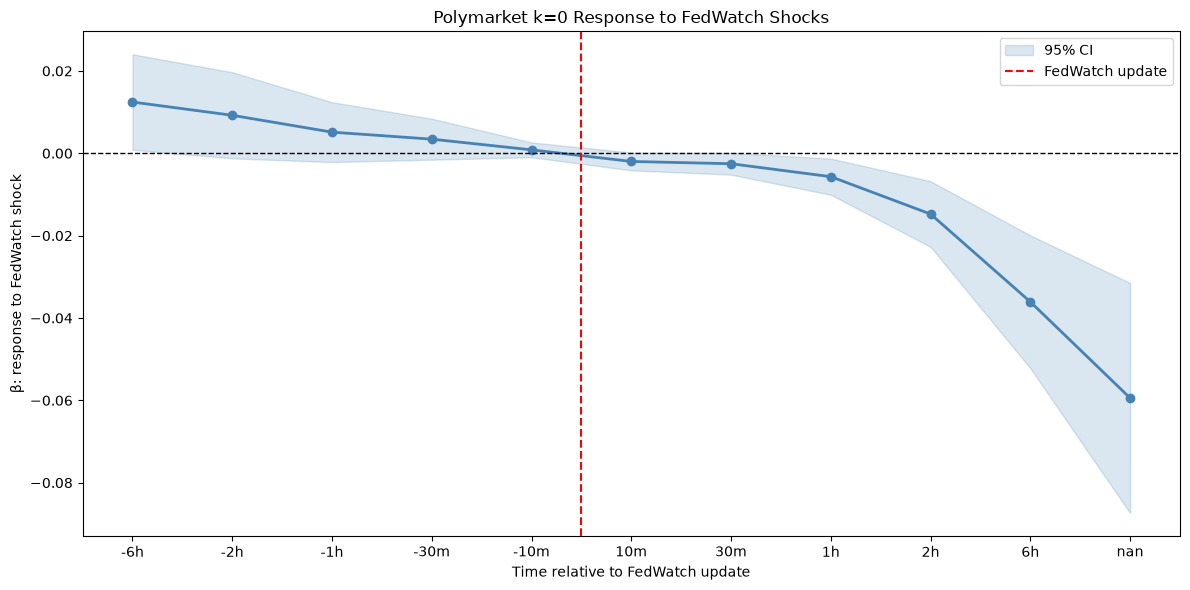

In [127]:
plot_data = results_df

k0 = plot_data[
    plot_data["k"] == 0
].copy()

horizon_order = [
    "-6h",
    "-2h",
    "-1h",
    "-30m",
    "-10m",
    "10m",
    "30m",
    "1h",
    "2h",
    "6h",
    # "24h"  # I'd initially leave this out
]

k0["horizon"] = pd.Categorical(
    k0["horizon"],
    categories=horizon_order,
    ordered=True
)

k0 = k0.sort_values("horizon")

k0["se"] = k0["beta"] / k0["tstat"]

k0["ci_low"] = k0["beta"] - 1.96 * k0["se"]
k0["ci_high"] = k0["beta"] + 1.96 * k0["se"]

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(k0))

pre_mask = k0["horizon"].astype(str).str.startswith("-")
post_mask = ~pre_mask

plt.figure(figsize=(12, 6))

# Confidence interval
plt.fill_between(
    x,
    k0["ci_low"].values,
    k0["ci_high"].values,
    color="steelblue",
    alpha=0.20,
    label="95% CI"
)

# Main coefficient line
plt.plot(
    x,
    k0["beta"].values,
    color="steelblue",
    marker="o",
    linewidth=2
)

# Zero line
plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

# Event
plt.axvline(
    4.5,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="FedWatch update"
)

plt.xticks(
    x,
    k0["horizon"].astype(str)
)

plt.xlabel("Time relative to FedWatch update")
plt.ylabel("β: response to FedWatch shock")

plt.title(
    "Polymarket k=0 Response to FedWatch Shocks"
)

plt.legend()
plt.tight_layout()
plt.show()


In [130]:
baseline

,snapshot_date,meeting_date,expected_rate,probability_mass,effective_date,current_rate,realized_cuts_2026,current_rate_2026,expected_cuts_remaining,expected_total_cuts_2026,fedwatch_shock,fedwatch_shock_rate,k,snapshot_time,price
0,2025-10-30 12:54:13+00:00,2026-12-09,305.772750,1.000000,2025-10-30,387.5,0.0,362.5,2.269090,2.269090,NaN,NaN,0,2025-10-30 12:50:00+00:00,0.0500
1,2025-10-30 12:54:13+00:00,2026-12-09,305.772750,1.000000,2025-10-30,387.5,0.0,362.5,2.269090,2.269090,NaN,NaN,12,2025-10-30 12:50:00+00:00,0.0865
2,2025-10-30 12:54:13+00:00,2026-12-09,305.772750,1.000000,2025-10-30,387.5,0.0,362.5,2.269090,2.269090,NaN,NaN,11,2025-10-30 12:50:00+00:00,0.0105
3,2025-10-30 12:54:13+00:00,2026-12-09,305.772750,1.000000,2025-10-30,387.5,0.0,362.5,2.269090,2.269090,NaN,NaN,10,2025-10-30 12:50:00+00:00,0.0160
4,2025-10-30 12:54:13+00:00,2026-12-09,305.772750,1.000000,2025-10-30,387.5,0.0,362.5,2.269090,2.269090,NaN,NaN,8,2025-10-30 12:50:00+00:00,0.0125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2634,2026-08-21 12:54:13+00:00,2026-12-09,387.833737,1.000001,2026-07-30,362.5,0.0,362.5,-1.013349,-1.013349,-0.097069,2.426725,1,2026-08-21 12:50:00+00:00,0.0950
2635,2026-08-21 12:54:13+00:00,2026-12-09,387.833737,1.000001,2026-07-30,362.5,0.0,362.5,-1.013349,-1.013349,-0.097069,2.426725,0,2026-08-21 12:50:00+00:00,0.8675
2636,2026-08-21 12:54:13+00:00,2026-12-09,387.833737,1.000001,2026-07-30,362.5,0.0,362.5,-1.013349,-1.013349,-0.097069,2.426725,11,2026-08-21 12:50:00+00:00,0.0005
2637,2026-08-21 12:54:13+00:00,2026-12-09,387.833737,1.000001,2026-07-30,362.5,0.0,362.5,-1.013349,-1.013349,-0.097069,2.426725,5,2026-08-21 12:50:00+00:00,0.0025


In [149]:
bt["target_time"]

0      2025-10-30 14:00:00+00:00
1      2025-10-30 14:00:00+00:00
2      2025-10-30 14:00:00+00:00
3      2025-10-30 14:00:00+00:00
4      2025-10-30 14:00:00+00:00
                  ...           
2634   2026-08-21 14:00:00+00:00
2635   2026-08-21 14:00:00+00:00
2636   2026-08-21 14:00:00+00:00
2637   2026-08-21 14:00:00+00:00
2638   2026-08-21 14:00:00+00:00
Name: target_time, Length: 2639, dtype: datetime64[us, UTC]

In [223]:
horizons = {
    "10m": pd.Timedelta(minutes=10),
    "30m": pd.Timedelta(minutes=30),
    "1h": pd.Timedelta(hours=1),
    "2h": pd.Timedelta(hours=2),
    "6h": pd.Timedelta(hours=6),
    "24h": pd.Timedelta(hours=24),
}
thresholds = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.10, 0.15]
res = 0
for h in horizons:

    for t in thresholds:
        bt = baseline.copy()
        bt = bt.rename(columns={
            "snapshot_date": "fedwatch_time",
            "snapshot_time": "poly_pre_time",
            "price": "pre_price"
        }).copy()

        bt = bt[bt["k"] == 0]

        bt = pd.merge_asof(
            bt.sort_values("fedwatch_time"),
            poly_long.sort_values("snapshot_time"),
            left_on="fedwatch_time",
            right_on="snapshot_time",
            by="k",
            direction="forward",
            tolerance=pd.Timedelta(minutes=10),
            suffixes=("", "_entry")
        )

        bt = bt.rename(columns={
            "snapshot_time": "entry_time",
            "price": "entry_price"
        })

        bt["immediate_change"] = (
            bt["entry_price"] - bt["pre_price"]
        )

        bt["entry_delay"] = (
            bt["entry_time"] - bt["fedwatch_time"]
        )

        bt["target_time"] = (
            (bt["entry_time"] + pd.Timedelta(hours=36))
        )

        bt["target_time"] = bt["target_time"].astype("datetime64[ms, UTC]")
        bt = bt.dropna(subset=["target_time"])
        bt = pd.merge_asof(
            bt.sort_values("target_time"),
            poly_long.sort_values("snapshot_time"),
            left_on="target_time",
            right_on="snapshot_time",
            by="k",
            direction="forward",
            tolerance=pd.Timedelta(minutes=10),
            suffixes=("", "_exit")
        )

        bt = bt.rename(columns={
            "snapshot_time": "exit_time",
            "price": "exit_price"
        })
        bt["position"] = 0

        # FedWatch says MORE cuts than yesterday
        bt.loc[
            (bt["fedwatch_shock"] > 0) &
            (bt["k"] > bt["expected_total_cuts_2026"]),
            "position"
        ] = 1

        bt.loc[
            (bt["fedwatch_shock"] > 0) &
            (bt["k"] < bt["expected_total_cuts_2026"]),
            "position"
        ] = -1


        # FedWatch says FEWER cuts than yesterday
        bt.loc[
            (bt["fedwatch_shock"] < t) &
            (bt["k"] > bt["expected_total_cuts_2026"]),
            "position"
        ] = -1

        bt.loc[
            (bt["fedwatch_shock"] < t) &
            (bt["k"] < bt["expected_total_cuts_2026"]),
            "position"
        ] = 1

        bt["pnl_1h"] = (
            bt["position"] *
            (bt["exit_price"] - (0.04 * bt["exit_price"] * (1 - bt["exit_price"])) - bt["entry_price"] - (0.04 * bt["entry_price"] * (1 - bt["entry_price"])))
        )

        trades = bt[
            (bt["position"] != 0) &
            bt["entry_price"].notna() &
            bt["exit_price"].notna()
        ].copy()
        print("h:", h, "t:", t)
        print("Trades:", len(trades))
        print("Mean P&L:", trades["pnl_1h"].mean())
        print("Total P&L:", trades["pnl_1h"].sum())
        print("Hit rate:", (trades["pnl_1h"] > 0).mean())
        res = max(res,  trades["pnl_1h"].sum())

# bt

h: 10m t: 0.0
Trades: 192
Mean P&L: 0.0012982591145833321
Total P&L: 0.24926574999999979
Hit rate: 0.5520833333333334
h: 10m t: 0.01
Trades: 192
Mean P&L: 0.0015886467187499985
Total P&L: 0.3050201699999997
Hit rate: 0.5625
h: 10m t: 0.02
Trades: 192
Mean P&L: 0.0019151000520833327
Total P&L: 0.3676992099999999
Hit rate: 0.5677083333333334
h: 10m t: 0.03
Trades: 192
Mean P&L: 0.002099359739583332
Total P&L: 0.4030770699999997
Hit rate: 0.578125
h: 10m t: 0.04
Trades: 192
Mean P&L: 0.00258590234375
Total P&L: 0.49649325
Hit rate: 0.5833333333333334
h: 10m t: 0.05
Trades: 192
Mean P&L: 0.003046192864583334
Total P&L: 0.5848690300000001
Hit rate: 0.5989583333333334
h: 10m t: 0.06
Trades: 192
Mean P&L: 0.00335967453125
Total P&L: 0.64505751
Hit rate: 0.6145833333333334
h: 10m t: 0.08
Trades: 192
Mean P&L: 0.003958289947916668
Total P&L: 0.7599916700000002
Hit rate: 0.6197916666666666
h: 10m t: 0.1
Trades: 192
Mean P&L: 0.0034370664062500014
Total P&L: 0.6599167500000003
Hit rate: 0.6041666

In [ ]:
# Finally, your current result tells an interesting economic story
# If it survives out-of-sample, your narrative could be:

# "I found evidence that Polymarket's zero-cut contract underreacts to changes in the Fed Funds futures distribution. In particular, sufficiently large revisions in expected 2026 cuts predict subsequent movements in the zero-cut contract over short horizons. The strongest in-sample specification was a 30-minute holding period following revisions of at least 8 basis points in expected cuts."


# TRADING SIGNAL


# September 15-16
# t >= 0.08
# exit time  = 30m
# k = 0 rate cuts

In [233]:
res

np.float64(0.7599916700000002)

In [219]:
trades = bt[
    (bt["position"] != 0) &
    bt["entry_price"].notna() &
    bt["exit_price"].notna()
].copy()

print("Trades:", len(trades))
print("Mean P&L:", trades["pnl_1h"].mean())
print("Total P&L:", trades["pnl_1h"].sum())
print("Hit rate:", (trades["pnl_1h"] > 0).mean())

Trades: 192
Mean P&L: 0.00335967453125
Total P&L: 0.64505751
Hit rate: 0.6145833333333334


In [220]:
trades.groupby("k")["pnl_1h"].agg(
    trades="count",
    mean="mean",
    total="sum",
    hit_rate=lambda x: (x > 0).mean()
).sort_index()

,trades,mean,total,hit_rate
k,,,,
0,192,0.00336,0.645058,0.614583


In [221]:
trades.groupby(
    trades["fedwatch_shock"] > 0
)["pnl_1h"].agg(
    trades="count",
    mean="mean",
    total="sum",
    hit_rate=lambda x: (x > 0).mean()
)

,trades,mean,total,hit_rate
fedwatch_shock,,,,
False,101,0.001266,0.127849,0.584158
True,91,0.005684,0.517208,0.648352


In [197]:
from scipy import stats

x = trades["pnl_1h"].dropna()

t_stat, p_value = stats.ttest_1samp(x, 0)

print("Mean P&L:", x.mean())
print("t-stat:", t_stat)
print("p-value:", p_value)

Mean P&L: 0.0012982591145833321
t-stat: 0.6048243821497435
p-value: 0.5460135526548292


In [170]:
bt["target_time"].isna().sum()

np.int64(79)

In [165]:
poly_long.head(30)

,snapshot_time,k,price
0,2025-09-29 22:40:00+00:00,0,0.495
46098,2025-09-29 22:40:00+00:00,1,0.500
92988,2025-09-29 22:40:00+00:00,2,0.495
139596,2025-09-29 22:40:00+00:00,3,0.495
186670,2025-09-29 22:40:00+00:00,4,0.495
233809,2025-09-29 22:40:00+00:00,5,0.495
280840,2025-09-29 22:40:00+00:00,6,0.495
327697,2025-09-29 22:40:00+00:00,7,0.495
374160,2025-09-29 22:40:00+00:00,8,0.200
421190,2025-09-29 22:40:00+00:00,9,0.495


In [158]:
bt["entry_time"].isna().mean()

np.float64(0.02993558165971959)

In [16]:
for i, j in t.iloc[0].items():
    print(i, j)

id 616903
question Will 1 Fed rate cut happen in 2026?
conditionId 0x5e082f0b57f47a29044aa35b4c5658393122e659d5feae521c06b57cdd7f905c
slug will-1-fed-rate-cut-happen-in-2026
resolutionSource 
endDate 2026-12-31T00:00:00Z
liquidity 218087.9904
startDate 2025-09-29T22:24:47.834711Z
image https://polymarket-upload.s3.us-east-2.amazonaws.com/how-many-fed-rate-cuts-in-2025-9qstZkSL1dn0.jpg
icon https://polymarket-upload.s3.us-east-2.amazonaws.com/how-many-fed-rate-cuts-in-2025-9qstZkSL1dn0.jpg
description This market will resolve according to the exact amount of cuts of 25 basis points in 2026 by the Fed (including any cuts made during the December meeting).

Emergency rate cuts outside of scheduled FOMC meetings will also count toward the total number of cuts in 2026. This market will remain open until December 31, 2026, 11:59 PM ET, to account for any such emergency actions.

For example, if the Fed cuts rates by 50 bps after a meeting, it would be considered 2 cuts (of 25 bps each).

Thi

In [10]:
for i, j in all_markets_df.iloc[0].items():
    print(i, j)

id 559651
question Xi Jinping out before 2027?
conditionId 0xa467b14d51f01b957109d9cbb1d6c124fab2a089d52ed8f471d23c2812e743b7
slug xi-jinping-out-before-2027
resolutionSource 
endDate 2026-12-31T00:00:00Z
liquidity 168030.01867
startDate 2025-07-03T20:37:00.228Z
image https://polymarket-upload.s3.us-east-2.amazonaws.com/xi-jinping-out-in-2025-EjF4SM20eaa3.jpg
icon https://polymarket-upload.s3.us-east-2.amazonaws.com/xi-jinping-out-in-2025-EjF4SM20eaa3.jpg
description This market will resolve to "Yes" if China's General Secretary of the Communist Party, Xi Jinping, is removed from power for any length of time between July 3, 2025, and December 31, 2026, 11:59 PM ET. Otherwise, this market will resolve to "No".

CCP General Secretary Xi Jinping will be considered removed from power if he announces his resignation from his role as General Secretary, or is otherwise dismissed, detained, disqualified, or otherwise loses his position or is prevented from fulfilling his duties as General Secr

In [36]:
import re
import json
import calendar
import numpy as np
import pandas as pd
from dateutil import parser
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor

class MarketScanner:

    def __init__(self, api):
        self.api = api


    def scan_market(self, markets_df):

        markets_df = markets_df[
            (markets_df["acceptingOrders"] == True) &
            (markets_df["enableOrderBook"] == True)
        ]

        markets_df["tokens"] = markets_df["clobTokenIds"].apply(json.loads)
        markets_df["yes_token"] = markets_df["tokens"].apply(lambda x: x[0])
        markets_df["no_token"] = markets_df["tokens"].apply(lambda x: x[1])

        book_cols = [
            "yes_book",
            "no_book",
            "yes_bid",
            "yes_ask",
            "no_bid",
            "no_ask",
        ]

        with ThreadPoolExecutor(max_workers=30) as executor:
            markets_df[book_cols] = list(executor.map(
                self.get_books, (row for _, row in markets_df.iterrows())))

        # markets_df[["iv", "model_prob", "buy_yes_fee", "sell_yes_fee", "buy_no_fee", "sell_no_fee",
        #     "buy_yes_ev", "sell_yes_ev", "buy_no_ev", "sell_no_ev",
        #     "buy_yes_kelly", "sell_yes_kelly", "buy_no_kelly", "sell_no_kelly"]] = markets_df.apply(
        #     lambda row: self.calculate_market_ev(row, s), axis=1)

        # markets_df = markets_df.dropna(subset=["buy_yes_ev"])

        # ev_cols = [
        #     "buy_yes_ev",
        #     "sell_yes_ev",
        #     "buy_no_ev",
        #     "sell_no_ev"
        # ]

        # markets_df["best_ev"] = markets_df[ev_cols].max(axis=1)
        # markets_df["best_action"] = markets_df[ev_cols].idxmax(axis=1)

        # opportunities_df = markets_df[markets_df["best_ev"] > 0].sort_values("best_ev", ascending=False)

        # # new sorting order
        # cols = ["question", "endDate", "yes_ask", "yes_bid", "no_ask", "no_bid", "model_prob"]

        # markets_df = markets_df[cols + [c for c in markets_df.columns if c not in cols]]
        # opportunities_df = opportunities_df[cols + [c for c in opportunities_df.columns if c not in cols]]

        self.markets_df = markets_df
        # self.opportunities_df = opportunities_df

        return markets_df

    def extract_currency(self, row, CURRENCIES):

        text = f'{row.get("question", "")} {row.get("description", "")}'.lower()

        for keyword, currency in CURRENCIES.items():
            if re.search(rf'\b{re.escape(keyword)}\b', text):
                return currency

        return None


    def extract_strike(self, question):
    
        match = re.search(
            r'\$([\d,]+(?:\.\d+)?)([kmb])?\b',
            question,
            re.IGNORECASE
        )

        if not match:
            return None

        value = float(match.group(1).replace(",", ""))
        suffix = (match.group(2) or "").lower()

        multiplier = {
            "k": 1e3,
            "m": 1e6,
            "b": 1e9,
        }

        return value * multiplier.get(suffix, 1)


    def extract_expiry(self, question, slug=None):
        # Try full date in question
        # m = match
        m = re.search(
            r'(January|February|March|April|May|June|July|August|September|October|November|December) \d{1,2}, \d{4}',
            question
        )
        if m:
            return parser.parse(m.group()).strftime("%Y%m%d")

        if slug:
            slug = slug.lower()

            # Full date in slug: december-31-2026
            m = re.search(
                r'(january|february|march|april|may|june|july|august|september|october|november|december)-(\d{1,2})-(\d{4})',
                slug
            )
            if m:
                month, day, year = m.groups()
                return parser.parse(f"{day} {month} {year}").strftime("%Y%m%d")

            # Month only: august-2026
            m = re.search(
                r'(january|february|march|april|may|june|july|august|september|october|november|december)-(\d{4})',
                slug
            )
            if m:
                month_name, year = m.groups()
                month = parser.parse(month_name).month
                year = int(year)

                last_day = calendar.monthrange(year, month)[1]
                return f"{year}{month:02d}{last_day:02d}"

        return None

    def parse_crypto_market_type(self, question):

        q = question.lower()

        # ----------------------
        # Direction
        # ----------------------
        if any(word in q for word in [
            "dip",
            "fall",
            "drop",
            "below",
            "under",
            "crash"
        ]):
            direction = "down"

        elif any(word in q for word in [
            "reach",
            "hit",
            "touch",
            "above",
            "over",
            "exceed"
        ]):
            direction = "up"

        else:
            direction = None

        # ----------------------
        # Event type
        # ----------------------
        if any(word in q for word in [
            "reach",
            "hit",
            "touch",
            "dip to",
            "fall to",
            "drop to",
            "crash to"
        ]):
            event_type = "touch"

        elif any(word in q for word in [
            "be above",
            "above on",
            "close above",
            "be below",
            "below on",
            "close below",
            "finish above",
            "finish below"
        ]):
            event_type = "expiry"

        else:
            event_type = None

        return {
            "direction": direction,
            "event_type": event_type
        }
    

    def get_books(self, row):

        yes_book = self.api.orderbook(row["yes_token"])
        no_book = self.api.orderbook(row["no_token"])

        yes_bids = yes_book.get("bids", [])
        yes_asks = yes_book.get("asks", [])

        no_bids = no_book.get("bids", [])
        no_asks = no_book.get("asks", [])

        return pd.Series({
            "yes_book": yes_book,
            "no_book": no_book,

            # Highest price someone is bidding
            "yes_bid": (max(float(x["price"]) for x in yes_bids) if yes_bids else None),

            # Lowest price someone is asking
            "yes_ask": (min(float(x["price"]) for x in yes_asks) if yes_asks else None),

            # Highest price someone is bidding
            "no_bid": (max(float(x["price"]) for x in no_bids) if no_bids else None),

            # Lowest price someone is asking
            "no_ask": (min(float(x["price"]) for x in no_asks) if no_asks else None)
        })


    def calculate_ev(
            self,
            model_prob,
            best_ask_yes,
            best_bid_yes,
            best_ask_no,
            best_bid_no,
            fee_rate=0.07,
            kelly_fraction = 0.5
        ):
        
        """
        Expected PnL per contract for Polymarket.

        model_prob : P(YES)
        fee_rate   : taker fee rate (e.g. 0.07 for crypto markets)

        Assumes:
        - you are a taker
        - fee = fee_rate * price * (1 - price)
        - settlement has no fee
        """

        def is_valid(price):
            return pd.notna(price)

        def fee(price, fee_rate):
            #fee = C × feeRate × p × (1 - p)
            #Where C = number of shares traded and p = price of the shares.
            return fee_rate * price * (1 - price)

        p_yes = model_prob
        p_no = 1 - p_yes

        # -------------------------
        # BUY YES
        # -------------------------
        if is_valid(best_ask_yes):
            buy_yes_cost = best_ask_yes + fee(best_ask_yes, fee_rate)

            profit_if_yes = 1 - buy_yes_cost
            cost_if_no = buy_yes_cost

            # EV: profit if yes - cost if no
            buy_yes_ev = p_yes * profit_if_yes - p_no * cost_if_no

            """
            p            : probability of winning
            win_profit   : net profit if the bet wins
            loss_amount  : net loss if the bet loses

            Returns the optimal Kelly fraction.
            """

            buy_yes_kelly = kelly_fraction * (buy_yes_ev / profit_if_yes) # fee adjusted kelly

            # -------------------------
            # SELL YES (short YES)
            # -------------------------
            sell_yes_credit = best_bid_yes - fee(best_bid_yes, fee_rate)

            profit_if_no = sell_yes_credit
            cost_if_yes = 1 - sell_yes_credit # need to pay the remaining of the $1 out of the credit you got, if yes happened

            # EV: profit if yes - cost if no
            sell_yes_ev = p_no * profit_if_no - p_yes * cost_if_yes

            sell_yes_kelly = kelly_fraction * (sell_yes_ev / profit_if_no)

        else:
            print("price not valid")
            buy_yes_ev = np.nan
            sell_yes_ev = np.nan
            buy_yes_kelly = np.nan
            sell_yes_kelly = np.nan
            
        # -------------------------
        # BUY NO
        # -------------------------
        if is_valid(best_ask_no):
            buy_no_cost = best_ask_no + fee(best_ask_no, fee_rate)

            profit_if_no = 1 - buy_no_cost
            cost_if_yes = buy_no_cost

            buy_no_ev = p_no * profit_if_no - p_yes * cost_if_yes

            buy_no_kelly = kelly_fraction * (buy_no_ev / profit_if_no)

            # -------------------------
            # SELL NO (short NO)
            # -------------------------
            sell_no_credit = best_bid_no - fee(best_bid_no, fee_rate)

            profit_if_yes = sell_no_credit
            cost_if_no = 1 - sell_no_credit

            sell_no_ev = p_yes * profit_if_yes - p_no * cost_if_no

            sell_no_kelly = kelly_fraction * (sell_no_ev / profit_if_yes)

        else:
            print("price not valid")
            buy_no_ev = np.nan
            sell_no_ev = np.nan
            buy_no_kelly = np.nan
            sell_no_kelly = np.nan
        
        print("buy_yes_ev:", buy_yes_ev)
        print("sell_yes_ev:", sell_yes_ev)
        print("buy_no_ev:", buy_no_ev)
        print("sell_no_ev:", sell_no_ev)
        print("buy_yes_kelly:", buy_yes_kelly)
        print("sell_yes_kelly:", sell_yes_kelly)
        print("buy_no_kelly:", buy_no_kelly)
        print("sell_no_kelly:", sell_no_kelly)
        print("")

        return {
            "buy_yes_fee": fee(best_ask_yes, fee_rate),
            "sell_yes_fee": fee(best_bid_yes, fee_rate),
            "buy_no_fee": fee(best_ask_no, fee_rate),
            "sell_no_fee": fee(best_bid_no, fee_rate),
            "buy_yes_ev": buy_yes_ev,
            "sell_yes_ev": sell_yes_ev,
            "buy_no_ev": buy_no_ev,
            "sell_no_ev": sell_no_ev,
            "buy_yes_kelly": buy_yes_kelly,
            "sell_yes_kelly": sell_yes_kelly,
            "buy_no_kelly": buy_no_kelly,
            "sell_no_kelly": sell_no_kelly,
        }


    def calculate_market_ev(self, row, s, confidence=0.7):

        currency = row["currency"]
        required_strike = row["strike"]
        T = row["T"]
        fee_rate = row["feeSchedule"]["rate"]

        iv = s.get_iv_from_surface(exchange=s, currency=currency, required_strike=required_strike, T=T)

        print("question:", row["question"])
        print("event type:", row["event_type"])
        print("direction:", row["direction"])
        print("currency:", currency)
        print("required strike:", required_strike)
        print('iv:', iv)

        if iv is None:
            return None

        if row["event_type"] == "touch":   
            
            if row["direction"] == "up":
                model_prob = s.prob_touch_above(spot=s.data[currency]["weighted_spot"],
                    required_strike=required_strike, iv=iv, T=T, r=0, q=0)

            elif row["direction"] == "down":
                model_prob = s.prob_touch_below(spot=s.data[currency]["weighted_spot"],
                    required_strike=required_strike, iv=iv, T=T, r=0, q=0)

        if row["event_type"] == "expiry":
            p_finish_above, p_finish_below = s.prob_finish(spot=s.data[currency]["weighted_spot"], 
                    required_strike=required_strike, iv=iv, T=T, r=0)

            if row["direction"] == "up":
                model_prob = p_finish_above

            elif row["direction"] == "down":
                model_prob = p_finish_below

        market_prob = (row["yes_bid"] + row["yes_ask"]) / 2
        model_prob_adjusted = (confidence * model_prob + (1-confidence) * market_prob)

        ev = self.calculate_ev(
            model_prob=model_prob,
            best_ask_yes=row["yes_ask"],
            best_bid_yes=row["yes_bid"],
            best_ask_no=row["no_ask"],
            best_bid_no=row["no_bid"],
            fee_rate=fee_rate
        )

        return pd.Series({
            "iv": iv,
            "model_prob": model_prob,
            **ev
        })


    def scan_arbitrage(self, arb_candidates_df):

        def fee(price, fee_rate):
            #fee = C × feeRate × p × (1 - p)
            #Where C = number of shares traded and p = price of the shares.
            return fee_rate * price * (1 - price)
        
        cross_market_arbs = []
        cross_market_arb_columns = [
            "currency",
            "event_type",
            "direction",
            "A_strike",
            "A_question",
            "A_id",
            "A_side",
            "A_price",
            "A_cost",
            "B_strike",
            "B_question",
            "B_id",
            "B_side",
            "B_price",
            "B_cost",
            "total_cost",
            "guaranteed_profit",
        ]

        for (currency, event_type, direction, strike), group_df in arb_candidates_df.groupby(["currency", "event_type", "direction", "strike"]):
            n = len(group_df)
            if n == 2:
                print(group_df)

                A = group_df.iloc[0]
                B = group_df.iloc[1]

                yes_A = A["yes_ask"] + fee(A["yes_ask"], A["feeSchedule"]["rate"])
                no_B = B["no_ask"] + fee(B["no_ask"], B["feeSchedule"]["rate"])

                yes_B = B["yes_ask"] + fee(B["yes_ask"], B["feeSchedule"]["rate"])
                no_A = A["no_ask"] + fee(A["no_ask"], A["feeSchedule"]["rate"])
                
                arb_1 = yes_A + no_B
                arb_2 = yes_B + no_A

                guaranteed_profit_1 = 1 - arb_1
                guaranteed_profit_2 = 1 - arb_2

                print("arb_1:", arb_1)
                print("arb_2:", arb_2)
                print("guaranteed_profit_1:", guaranteed_profit_1)
                print("guaranteed_profit_2:", guaranteed_profit_2)
                print("")

                if guaranteed_profit_1 > 0:
                    cross_market_arbs.append({
                    "currency": currency,
                    "event_type": event_type,
                    "direction": direction,

                    # Lower leg
                    "A_strike": A["strike"],
                    "A_question": A["question"],
                    "A_id": A["id"],
                    "A_side": "Yes",
                    "A_price": A["yes_ask"],
                    "A_cost": yes_A,

                    # Higher leg
                    "B_strike": B["strike"],
                    "B_question": B["question"],
                    "B_id": B["id"],
                    "B_side": "No",
                    "B_price": B["no_ask"],
                    "B_cost": no_B,

                    # Arb
                    "total_cost": arb_1,
                    "guaranteed_profit": guaranteed_profit_1,
                })

                if guaranteed_profit_2 > 0:
                    cross_market_arbs.append({
                    "currency": currency,
                    "event_type": event_type,
                    "direction": direction,

                    # Lower leg
                    "A_strike": A["strike"],
                    "A_question": A["question"],
                    "A_id": A["id"],
                    "A_side": "No",
                    "A_price": A["no_ask"],
                    "A_cost": no_A,

                    # Higher leg
                    "B_strike": B["strike"],
                    "B_question": B["question"],
                    "B_id": B["id"],
                    "B_side": "Yes",
                    "B_price": B["yes_ask"],
                    "B_cost": yes_B,

                    # Arb
                    "total_cost": arb_2,
                    "guaranteed_profit": guaranteed_profit_2,
                })

        cross_market_arb_df = pd.DataFrame(cross_market_arbs, columns=cross_market_arb_columns)


        vertical_arbs = []
        vertical_arb_columns = [
            "currency",
            "event_type",
            "direction",
            "lower_strike",
            "lower_question",
            "lower_id",
            "lower_side",
            "lower_price",
            "lower_cost",
            "higher_strike",
            "higher_question",
            "higher_id",
            "higher_side",
            "higher_price",
            "higher_cost",
            "total_cost",
            "guaranteed_profit",
        ]

        for (currency, event_type, direction), group_df in arb_candidates_df.groupby(["currency", "event_type", "direction"]):
            group_df = group_df.sort_values("strike").reset_index(drop=True)
            n = len(group_df)
            
            if direction == "up":
                print("up\n")

                for i in range(1, n):
                    lower = group_df.iloc[i - 1]
                    higher = group_df.iloc[i]

                    lower_cost = lower["yes_ask"] + fee(lower["yes_ask"], lower["feeSchedule"]["rate"])

                    higher_cost = higher["no_ask"] + fee(higher["no_ask"], higher["feeSchedule"]["rate"])

                    cost = lower_cost + higher_cost
                    guaranteed_profit = 1 - cost

                    print("lower_cost:", lower_cost)
                    print("higher_cost:", higher_cost)
                    print("cost:", cost)
                    print("guaranteed_profit:", guaranteed_profit)
                    print("")

                    if guaranteed_profit > 0:
                        vertical_arbs.append({
                        "currency": currency,
                        "event_type": event_type,
                        "direction": direction,

                        # Lower leg
                        "lower_strike": lower["strike"],
                        "lower_question": lower["question"],
                        "lower_id": lower["id"],
                        "lower_side": "Yes",
                        "lower_price": lower["yes_ask"],
                        "lower_cost": lower_cost,

                        # Higher leg
                        "higher_strike": higher["strike"],
                        "higher_question": higher["question"],
                        "higher_id": higher["id"],
                        "higher_side": "No",
                        "higher_price": higher["no_ask"],
                        "higher_cost": higher_cost,

                        # Arb
                        "total_cost": cost,
                        "guaranteed_profit": guaranteed_profit,
                    })

            elif direction == "down":
                print("down\n")

                for i in range(1, n):
                    lower = group_df.iloc[i - 1]
                    higher = group_df.iloc[i]

                    lower_cost = lower["no_ask"] + fee(lower["no_ask"], lower["feeSchedule"]["rate"])

                    higher_cost = higher["yes_ask"] + fee(higher["yes_ask"], higher["feeSchedule"]["rate"])

                    cost = lower_cost + higher_cost
                    guaranteed_profit = 1 - cost

                    print("lower_cost:", lower_cost)
                    print("higher_cost:", higher_cost)
                    print("cost:", cost)
                    print("guaranteed_profit:", guaranteed_profit)
                    print("")

                    if guaranteed_profit > 0:
                        vertical_arbs.append({
                        "currency": currency,
                        "event_type": event_type,
                        "direction": direction,

                        # Lower leg
                        "lower_strike": lower["strike"],
                        "lower_question": lower["question"],
                        "lower_id": lower["id"],
                        "lower_side": "No",
                        "lower_price": lower["no_ask"],
                        "lower_cost": lower_cost,

                        # Higher leg
                        "higher_strike": higher["strike"],
                        "higher_question": higher["question"],
                        "higher_id": higher["id"],
                        "higher_side": "Yes",
                        "higher_price": higher["yes_ask"],
                        "higher_cost": higher_cost,

                        # Arb
                        "total_cost": cost,
                        "guaranteed_profit": guaranteed_profit,
                    })

        vertical_arb_df = pd.DataFrame(vertical_arbs, columns=vertical_arb_columns)

        return cross_market_arb_df, vertical_arb_df